In [121]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mis_dro.dataset import *
from mis_dro.plot import *
from mis_dro.newsvendor import newsvendor_cost_cvxpy

In [122]:
dgp = "contaminated_exp"

In [123]:
# df_list = []
# for name in ["cont_normal_9010_mmd", "cont_normal_9010_bas"]:
#     df_list.append(pd.read_csv(Path(f"/dcs/pg23/u1604520/misdro/results/opt_results/{name}/results.csv")))
# all_results_df = pd.concat(df_list)

all_results_df = pd.read_csv("/dcs/large/u1508153/misdro/mmd_newsvendor_1d/results.csv")

/tmp/dcs-tmp.u1508153/ipykernel_322482/3806443069.py:6: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  all_results_df = pd.read_csv("/dcs/large/u1508153/misdro/mmd_newsvendor_1d/results.csv")


In [124]:
all_results_df["num_observations"].unique(), all_results_df["num_posterior_samples"].unique(), all_results_df["num_likelihood_samples"].unique()
# all_results_df = all_results_df.loc[all_results_df["replication"] <= 100]

(array([100]), array([30,  1]), array([ 30, 900]))

In [125]:
results_df = preprocess_results_df(all_results_df, dgp)
agg_df = get_agg_df(results_df, ["algorithm", "dgp", "epsilon", "inference", "contamination"]) 
agg_df.head(3)

/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/plot.py:198: FutureWarning: The provided callable <function mean at 0x7fd1c3ef1a80> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/plot.py:198: FutureWarning: The provided callable <function std at 0x7fd1c3ef1bc0> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  agg_df = gb.agg(


out_of_sample_mean  \
algorithm   dgp              epsilon inference contamination                       
dro_bas_mmd contaminated_exp 0.0001  npl_mmd   0.0                     79.804569   
                                               0.1                     80.997672   
                                               0.2                     90.740837   

                                                              out_of_sample_var  \
algorithm   dgp              epsilon inference contamination                      
dro_bas_mmd contaminated_exp 0.0001  npl_mmd   0.0                 11152.747244   
                                               0.1                  9076.314008   
                                               0.2                  5961.448199   

                                                              sum_of_in_group_var  \
algorithm   dgp              epsilon inference contamination                        
dro_bas_mmd contaminated_exp 0.0001  npl_mmd   0.0                   10927.364131   
                                               0.1                    8875.897627   
                                               0.2                    5730.610336   

                                                              var_of_in_group_mean  \
algorithm   dgp              epsilon inference contamination                         
dro_bas_mmd contaminated_exp 0.0001  npl_mmd   0.0                      225.383113   
                                               0.1                      200.416381   
                                               0.2                      230.837863   

                                                              mean_solve_time  \
algorithm   dgp              epsilon inference contamination                    
dro_bas_mmd contaminated_exp 0.0001  npl_mmd   0.0                 318.404935   
                                               0.1                 240.630929   
                                               0.2                 349.508022   

                                                              std_solve_time  \
algorithm   dgp              epsilon inference contamination                   
dro_bas_mmd contaminated_exp 0.0001  npl_mmd   0.0                 30.703045   
                                               0.1                 26.058004   
                                               0.2                 42.151056   

                                                              mean_sample_time  \
algorithm   dgp              epsilon inference contamination                     
dro_bas_mmd contaminated_exp 0.0001  npl_mmd   0.0                   37.563384   
                                               0.1                   37.345794   
                                               0.2                   37.330459   

                                                              std_sample_time  
algorithm   dgp              epsilon inference contamination                   
dro_bas_mmd contaminated_exp 0.0001  npl_mmd   0.0                   4.051772  
                                               0.1                   3.445067  
                                               0.2                   3.511724

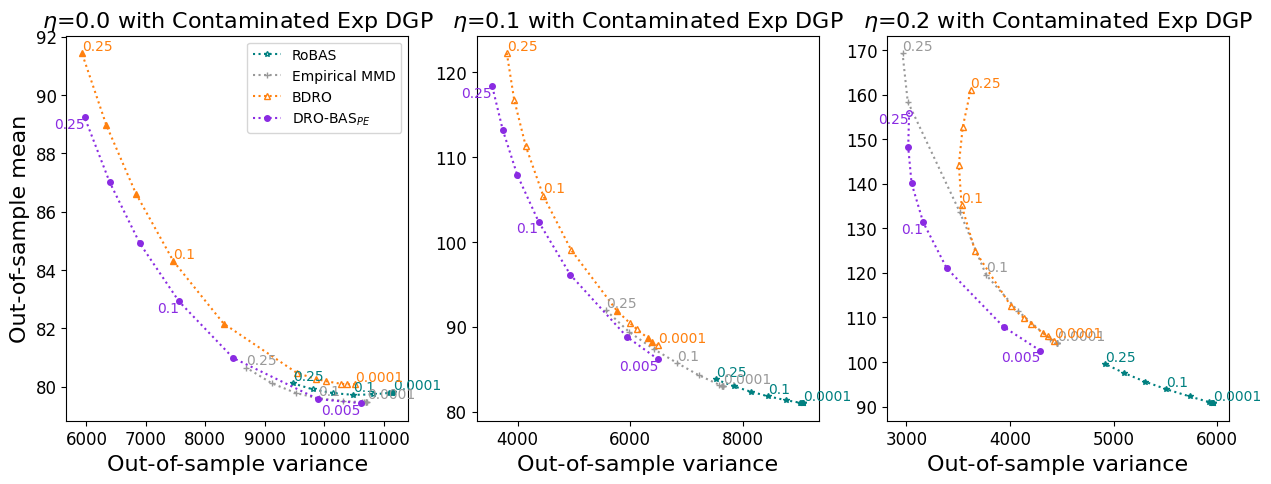

In [126]:
cont_list = agg_df.index.get_level_values("contamination").unique().tolist()
dgp_list = agg_df.index.get_level_values("dgp").unique().tolist()

nrows = len(dgp_list)
ncols = len(cont_list)

# agg_df = agg_df.loc[:, :, :0.2]

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=False, sharey=False, figsize=(5*ncols, nrows*5))
fig.subplots_adjust(wspace=0.2)
pd.options.mode.chained_assignment = None  # default='warn'
# fig.suptitle('Symmetric newsvendor', fontsize=16)
total_samples = 900
for i, dgp in enumerate(dgp_list):
    for j, cont in enumerate(cont_list):
        axis_df = agg_df.loc[:, dgp, :, :, cont]  
        axis_df.loc[:, "is_pareto_front"] = is_minimise_pareto_front(axis_df["out_of_sample_var"].values, axis_df["out_of_sample_mean"].values)
        for algorithm in axis_df.index.get_level_values("algorithm").unique():
            if algorithm == 'dro_bas_mmd':
                inference = "npl_mmd"
            elif algorithm in ['kl_bdro', 'kl_dro_bas', 'kl_pp']:
                inference = "bayes"
            else:
                inference = "empirical"
            df = axis_df.loc[algorithm, :, inference]
            alpha = 1.0
            is_labelled=True
            mean_variance_plot(axes[j], df, **algorithm_inference_style(algorithm, inference, label_inference=False), offset=0.0, is_labelled=is_labelled, alpha=alpha)
        if j == 0:
            axes[j].legend(fontsize=10)
            axes[j].set_ylabel("Out-of-sample mean", fontsize=16)
        axes[j].set_title("$\eta$" + f"={cont_list[j]} with {NiceNameDGP[dgp]}", fontsize=16) 
        axes[j].tick_params(axis='both', which='major', labelsize=12)
        axes[j].set_xlabel("Out-of-sample variance", fontsize=16)

In [132]:
solve_time_df = get_agg_df(results_df, ["algorithm", "contamination"])
solve_time_df = solve_time_df.round(decimals=2)
solve_time_df["str_solve_time"] = solve_time_df[["mean_solve_time", "std_solve_time"]].apply(
    lambda x: f"{x['mean_solve_time']} ({x['std_solve_time']})", axis=1
)
solve_time_df["str_sample_time"] = solve_time_df[["mean_sample_time", "std_sample_time"]].apply(
    lambda x: f"{x['mean_sample_time']} ({x['std_sample_time']})", axis=1
)
print(solve_time_df["str_solve_time"].unstack(level="algorithm").to_latex())

\begin{tabular}{lllll}
\toprule
algorithm & dro_bas_mmd & empirical_mmd & kl_bdro & kl_dro_bas \\
contamination &  &  &  &  \\
\midrule
0.000000 & 298.27 (40.39) & 5.47 (0.62) & 0.42 (0.06) & 0.4 (0.06) \\
0.100000 & 288.75 (42.85) & 5.29 (0.49) & 0.43 (0.06) & 0.41 (0.05) \\
0.200000 & 281.69 (51.82) & 5.17 (0.47) & 0.44 (0.06) & 0.42 (0.06) \\
\bottomrule
\end{tabular}



/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/plot.py:198: FutureWarning: The provided callable <function mean at 0x7fd1c3ef1a80> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/plot.py:198: FutureWarning: The provided callable <function std at 0x7fd1c3ef1bc0> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  agg_df = gb.agg(


In [133]:
print(solve_time_df["str_sample_time"].unstack(level="algorithm").to_latex())

\begin{tabular}{lllll}
\toprule
algorithm & dro_bas_mmd & empirical_mmd & kl_bdro & kl_dro_bas \\
contamination &  &  &  &  \\
\midrule
0.000000 & 37.56 (4.04) & 0.0 (0.0) & 0.1 (0.01) & 0.0 (0.0) \\
0.100000 & 37.35 (3.44) & 0.0 (0.0) & 0.1 (0.01) & 0.0 (0.0) \\
0.200000 & 37.33 (3.5) & 0.0 (0.0) & 0.1 (0.01) & 0.0 (0.0) \\
\bottomrule
\end{tabular}



In [128]:
from mis_dro.main import POSTERIOR_GB_COLS

npl_samples_dir = Path("/dcs/large/u1508153/misdro/npl_samples_newsvendor_1d")
# npl_df = results_df.loc[results_df["inference"] == "npl_mmd"]
settings_df = pd.read_csv(npl_samples_dir / "npl_settings.csv")

merged_df = results_df.merge(settings_df, how="left", on=POSTERIOR_GB_COLS)
merged_df["npl_uuid"]

KeyError: 'npl_uuid'

In [ ]:
times_df = pd.concat([pd.read_csv(npl_samples_dir / npl_uuid / f"npl_times_{npl_uuid}.csv") for npl_uuid in settings_df["npl_uuid"]])
times_df

,replication,npl_uuid,posterior_time
0,0,fdaf7c1c-7bbc-475f-997c-0471abf9470b,78.809292
1,1,fdaf7c1c-7bbc-475f-997c-0471abf9470b,76.005982
2,2,fdaf7c1c-7bbc-475f-997c-0471abf9470b,38.591716
3,3,fdaf7c1c-7bbc-475f-997c-0471abf9470b,38.180791
4,4,fdaf7c1c-7bbc-475f-997c-0471abf9470b,37.782680
...,...,...,...
195,195,eddec53a-e24e-4087-8ec3-381552862650,36.656614
196,196,eddec53a-e24e-4087-8ec3-381552862650,36.160709
197,197,eddec53a-e24e-4087-8ec3-381552862650,36.156451
198,198,eddec53a-e24e-4087-8ec3-381552862650,36.421258


In [ ]:
# merged_df.merge(times_df, on=["npl_uuid", "replication"], suffixes=('_drop', '')).drop("posterior_time_drop", axis="columns")
df_3 = merged_df.merge(times_df, on=["npl_uuid", "replication"], how="left", suffixes=('', '_drop'))
df_3[["posterior_time", "posterior_time_drop"]]

,posterior_time,posterior_time_drop
0,0.003113,78.539420
1,0.004506,61.253829
2,0.004077,37.698871
3,0.002346,37.581497
4,0.004258,37.188705
...,...,...
23995,0.000213,NaN
23996,0.000226,NaN
23997,0.000208,NaN
23998,0.000222,NaN


In [ ]:
df_3.loc[~(df_3['posterior_time_drop'].isna()), 'posterior_time'] = df_3['posterior_time_drop']
df_3 = df_3.drop("posterior_time_drop", axis=1)


,posterior_time,posterior_time_drop
0,78.539420,78.539420
1,61.253829,61.253829
2,37.698871,37.698871
3,37.581497,37.581497
4,37.188705,37.188705
...,...,...
23995,0.000213,NaN
23996,0.000226,NaN
23997,0.000208,NaN
23998,0.000222,NaN
